In [1]:
import os
import glob
import zarr
import numpy as np
from tqdm import tqdm
import dateutil

def get_zarr_dt(zarr_path):
    return dateutil.parser.parse(os.path.basename(zarr_path).split('.')[0])

scale = '25'
#zarrs = sorted(glob.glob(f'daily_osisaf_matchup_{scale}km/*.zarr'))
zarrs = sorted(glob.glob(f'cci_data/*.zarr'))


In [ ]:
# Aggregate samples for all months and years

years = sorted(list(set([get_zarr_dt(zarr).year for zarr in zarrs])))
months = sorted(list(set([get_zarr_dt(zarr).month for zarr in zarrs])))

yearmonth_samples = {}
for year in tqdm(years):
    for month in months:
        zarr_subset = [zarr for zarr in zarrs if get_zarr_dt(zarr).year == year and get_zarr_dt(zarr).month == month]
        asip_osisaf_tmp = []
        asip_nsidc_tmp = []
        osisaf_tmp = []
        osisaf_raw_tmp = []
        nsidc_tmp = []
        nt2_tmp = []
        for zarr_path in zarr_subset:
            z = zarr.open(zarr_path, mode='r')
            asip = z.datasets.asip_sic[:]
            osisaf = z.datasets.osisaf[:]
            nsidc = z.datasets.nsidc[:]
            valid_mask_osisaf = ~(np.isnan(asip) + np.isnan(osisaf))
            valid_mask_nsidc = ~(np.isnan(asip) + np.isnan(nsidc))
            if valid_mask_osisaf.any(): # Appending all pixels with valid data
                asip_osisaf_tmp.append(asip[valid_mask_osisaf])
                osisaf_tmp.append(osisaf[valid_mask_osisaf])
            if valid_mask_nsidc.any():
                asip_nsidc_tmp.append(asip[valid_mask_nsidc])
                nsidc_tmp.append(nsidc[valid_mask_nsidc])
        
        if len(asip_osisaf_tmp) > 0:
            if len(nsidc_tmp) > 0:
                yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {'asip_osisaf': np.hstack(asip_osisaf_tmp), 'osisaf': np.hstack(osisaf_tmp), 'asip_nsidc': np.hstack(asip_nsidc_tmp), 'nsidc': np.hstack(nsidc_tmp)}
            else:
                yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {'asip_osisaf': np.hstack(asip_osisaf_tmp), 'osisaf': np.hstack(osisaf_tmp), 'asip_nsidc': np.array([]), 'nsidc': np.array([])}
        else:
            yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {'asip_osisaf': np.array([]), 'osisaf': np.array([]), 'asip_nsidc': np.array([]), 'nsidc': np.array([])}

100%|██████████| 11/11 [04:06<00:00, 22.45s/it]


In [86]:
import pandas as pd

df = pd.DataFrame()

df['date'] = yearmonth_samples.keys()
df['support_osisaf'] = [len(yearmonth_samples[yearmonth]['asip_osisaf']) for yearmonth in yearmonth_samples.keys()]
df['support_nsidc'] = [len(yearmonth_samples[yearmonth]['asip_nsidc']) for yearmonth in yearmonth_samples.keys()]
df['mae_asip_osisaf'] = [np.nanmean(np.abs(yearmonth_samples[yearmonth]['asip_osisaf'] - yearmonth_samples[yearmonth]['osisaf'])) for yearmonth in yearmonth_samples.keys()]
df['mean_diff_asip_osisaf'] = [np.nanmean(yearmonth_samples[yearmonth]['asip_osisaf'] - yearmonth_samples[yearmonth]['osisaf']) for yearmonth in yearmonth_samples.keys()]
df['std_diff_asip_osisaf'] = [np.nanstd(yearmonth_samples[yearmonth]['asip_osisaf'] - yearmonth_samples[yearmonth]['osisaf']) for yearmonth in yearmonth_samples.keys()]
df['mae_asip_nsidc'] = [np.nanmean(np.abs(yearmonth_samples[yearmonth]['asip_nsidc'] - yearmonth_samples[yearmonth]['nsidc'])) for yearmonth in yearmonth_samples.keys()]
df['mean_diff_asip_nsidc'] = [np.nanmean(yearmonth_samples[yearmonth]['asip_nsidc'] - yearmonth_samples[yearmonth]['nsidc']) for yearmonth in yearmonth_samples.keys()]
df['std_diff_asip_nsidc'] = [np.nanstd(yearmonth_samples[yearmonth]['asip_nsidc'] - yearmonth_samples[yearmonth]['nsidc']) for yearmonth in yearmonth_samples.keys()]
#df['standard_error_of_the_mean'] = [np.nanstd(yearmonth_samples[yearmonth]['asip'] - yearmonth_samples[yearmonth]['osisaf']) / np.sqrt(len(yearmonth_samples['201901']['asip'])) for yearmonth in yearmonth_samples.keys()]


df['asip_osisaf_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['asip_osisaf']) for yearmonth in yearmonth_samples.keys()]
df['asip_nsidc_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['asip_nsidc']) for yearmonth in yearmonth_samples.keys()]
df['osisaf_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['osisaf']) for yearmonth in yearmonth_samples.keys()]
df['nsidc_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['nsidc']) for yearmonth in yearmonth_samples.keys()]
df = df.dropna(subset=['mae_asip_osisaf'])
#df = df.drop(df.index[-1]) # dropping October 2024 as it only contains a couple of days

/tmp/ipykernel_3805290/434233067.py:8: RuntimeWarning: Mean of empty slice
  df['mae_asip_osisaf'] = [np.nanmean(np.abs(yearmonth_samples[yearmonth]['asip_osisaf'] - yearmonth_samples[yearmonth]['osisaf'])) for yearmonth in yearmonth_samples.keys()]
/tmp/ipykernel_3805290/434233067.py:9: RuntimeWarning: Mean of empty slice
  df['mean_diff_asip_osisaf'] = [np.nanmean(yearmonth_samples[yearmonth]['asip_osisaf'] - yearmonth_samples[yearmonth]['osisaf']) for yearmonth in yearmonth_samples.keys()]
/home/twu/miniforge3/envs/asip_opr_forge/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3805290/434233067.py:11: RuntimeWarning: Mean of empty slice
  df['mae_asip_nsidc'] = [np.nanmean(np.abs(yearmonth_samples[yearmonth]['asip_nsidc'] - yearmonth_samples[yearmonth]['nsidc'])) for yearmonth in yearmonth_samples.keys()]
/tmp/ipykernel_3805290/434233067.

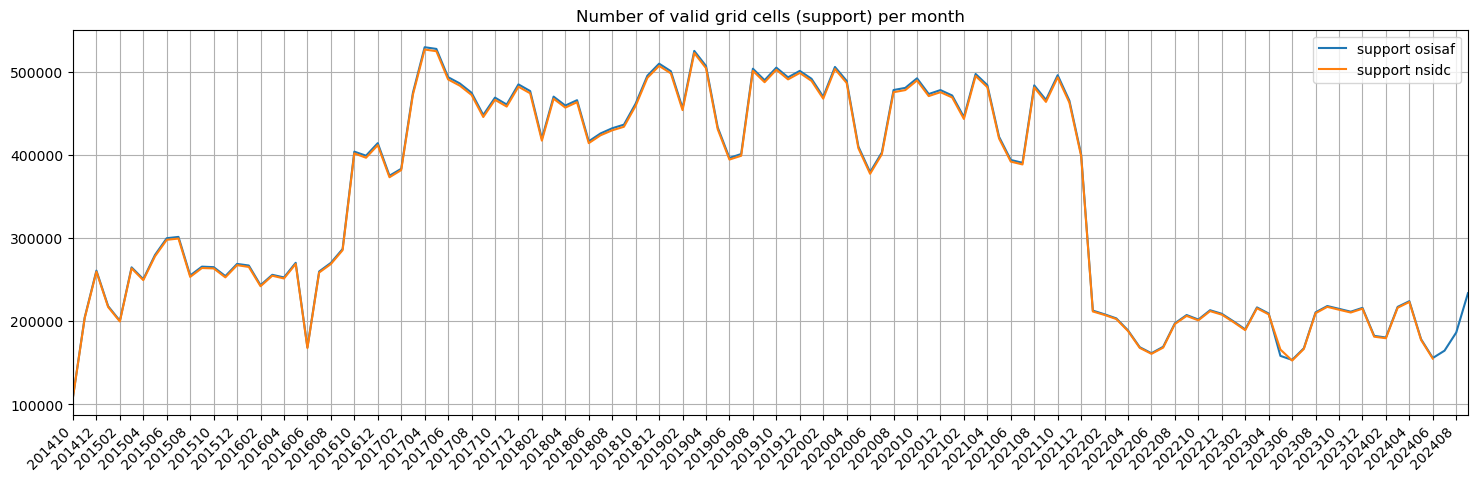

In [4]:
import matplotlib.pyplot as plt

df.loc[df.support_osisaf == 0, 'support_osisaf'] = np.nan
df.loc[df.support_nsidc == 0, 'support_nsidc'] = np.nan

plt.figure(figsize=(18, 5))

plt.plot(df['date'], df['support_osisaf'], label='support osisaf')
plt.plot(df['date'], df['support_nsidc'], label='support nsidc')

plt.grid(axis='y', which='both')
plt.grid(axis='x', which='both')

plt.title('Number of valid grid cells (support) per month')
plt.xticks(rotation=45, ha='right')
plt.xlim(0, len(df) - 1)
plt.legend()

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=60))

#plt.savefig(f'plots/asip_v_osisaf_monthly_support_{scale}km.png', bbox_inches='tight', dpi=300)

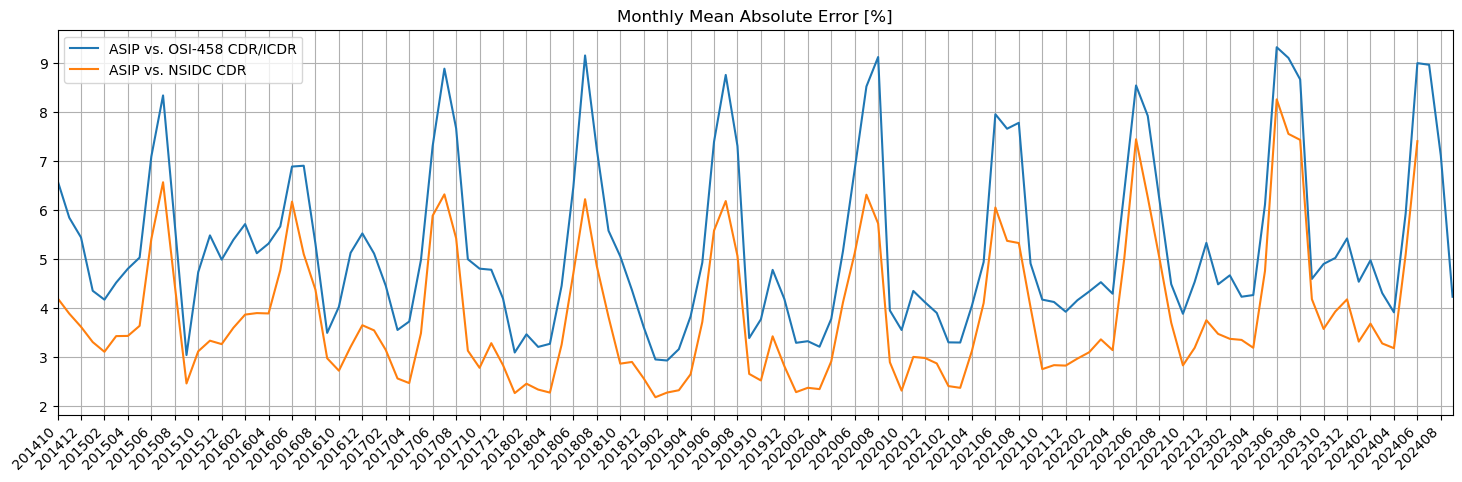

In [5]:
import matplotlib.pyplot as plt

#minimum_support = 30000

plt.figure(figsize=(18, 5))

#df.loc[df.support < minimum_support, 'asip_mae'] = np.nan
#df.loc[df.support < minimum_support, 'osisaf_mae'] = np.nan

color = 'tab:blue'
plt.plot(df.date, df.mae_asip_osisaf, label='ASIP vs. OSI-458 CDR/ICDR', color=color)
color = 'tab:orange'
plt.plot(df.date, df.mae_asip_nsidc, label='ASIP vs. NSIDC CDR', color=color)

plt.grid(axis='y', which='both')
plt.grid(axis='x', which='both')

plt.title(f'Monthly Mean Absolute Error [%]')
plt.xticks(rotation=45, ha='right')
plt.xlim(0, len(df) - 1)
plt.legend()

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=60))

#plt.savefig(f'plots/asip_v_osisaf_monthly_mae_{scale}km.png', bbox_inches='tight', dpi=300)

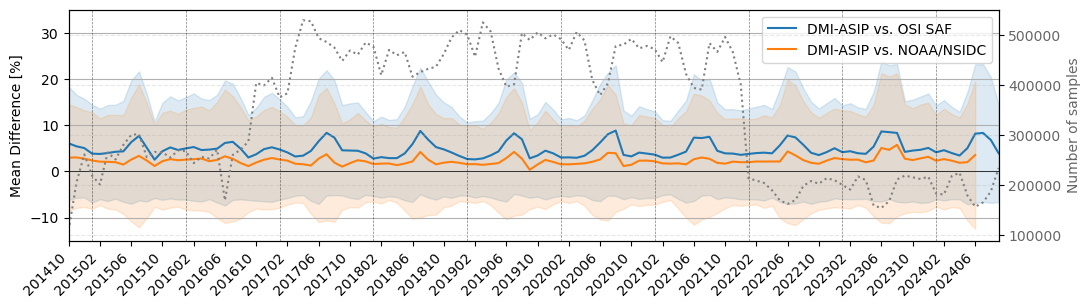

In [97]:
import matplotlib.pyplot as plt

#minimum_support = 30000

plt.figure(figsize=(12, 3))

#df.loc[df.support < minimum_support, 'asip_mae'] = np.nan
#df.loc[df.support < minimum_support, 'osisaf_mae'] = np.nan

fill_alpha = 0.15
std_alpha = 0.3
std_symbol = '--'

color = 'tab:blue'
plt.plot(df.date, df.mean_diff_asip_osisaf, label='DMI-ASIP vs. OSI SAF', color=color)
#plt.plot(df.date, df.mean_diff_asip_osisaf + df.std_diff_asip_osisaf, std_symbol, color=color, alpha=std_alpha)
#plt.plot(df.date, df.mean_diff_asip_osisaf - df.std_diff_asip_osisaf, std_symbol, color=color, alpha=std_alpha)
plt.fill_between(df.date, df.mean_diff_asip_osisaf - df.std_diff_asip_osisaf, df.mean_diff_asip_osisaf + df.std_diff_asip_osisaf, color=color, alpha=fill_alpha)
color = 'tab:orange'
plt.plot(df.date, df.mean_diff_asip_nsidc, label='DMI-ASIP vs. NOAA/NSIDC', color=color)
#plt.plot(df.date, df.mean_diff_asip_nsidc + df.std_diff_asip_nsidc, std_symbol, color=color, alpha=std_alpha)
#plt.plot(df.date, df.mean_diff_asip_nsidc - df.std_diff_asip_nsidc, std_symbol, color=color, alpha=std_alpha)
plt.fill_between(df.date, df.mean_diff_asip_nsidc - df.std_diff_asip_nsidc, df.mean_diff_asip_nsidc + df.std_diff_asip_nsidc, color=color, alpha=fill_alpha)

# add horizontal line at 0
plt.axhline(0, color='black', lw=0.5)

# add vertical lines for each year
for i in range(0, len(df), 12):
     plt.axvline(i + 3, color='black', linewidth=0.5, linestyle='--', alpha=0.5)

plt.grid(axis='y', which='both')
#plt.grid(axis='x', which='both')

#plt.title(f'Monthly Mean Difference')
plt.xticks(rotation=45, ha='right')
plt.xlim(0, len(df) - 1)
plt.ylim(-15, 35)
plt.legend(loc='upper right')

# add y label
plt.ylabel('Mean Difference [%]')

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=30))

# Plot support as a bar plot on a new y-axis
ax2 = plt.gca().twinx()
ax2.plot(df.date, df.support_osisaf, color='gray', alpha=1, label='Support OSI SAF', zorder=-5, linestyle=':') 
#ax2.bar(df.index, df.support_nsidc, color='tab:orange', alpha=0.2, label='Support NSIDC')
ax2.set_ylabel('Number of samples', alpha=0.6)
#ax2.set_yscale('log')
ax2.grid(True, axis='y', linestyle='--', alpha=0.3)

# Adjust transparency of y-axis tick labels
for tl in ax2.get_yticklabels():
     tl.set_alpha(0.6)

plt.savefig(f'paper_plots/asip_v_osisaf_and_nsidc_monthly_mean_diff_revised1.png', bbox_inches='tight', dpi=300)

In [9]:
df.support_osisaf

9      109045.0
10     204603.0
11     261051.0
12     218279.0
13     200703.0
         ...   
124    178566.0
125    155942.0
126    164757.0
127    186648.0
128    233911.0
Name: support_osisaf, Length: 120, dtype: float64

In [16]:
# get mean difference for each month in a year

df[df.date.str.endswith('01')].mean_diff_asip_osisaf.mean()

# get mean difference for each month in a year

for month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
    print(month, df[df.date.str.endswith(str(month).zfill(2))].mean_diff_asip_osisaf.mean(), df[df.date.str.endswith(str(month).zfill(2))].mean_diff_asip_nsidc.mean())


1 3.7781361572757257 2.1374422733517036
2 3.7811658202926965 2.0987696516069745
3 3.547251111006587 2.0008197738335176
4 3.6902994782610286 1.823394874519439
5 4.6848281167129455 1.8865561161527604
6 6.98093049998279 3.1822328471919237
7 7.892014028183366 3.715458728200265
8 6.847599335463961 2.919547392562606
9 3.844948876495624 1.4347971158209742
10 4.210284022068524 1.9517459215909536
11 4.53334227544091 2.4827802570872732
12 4.363411124260624 2.4596468284029447


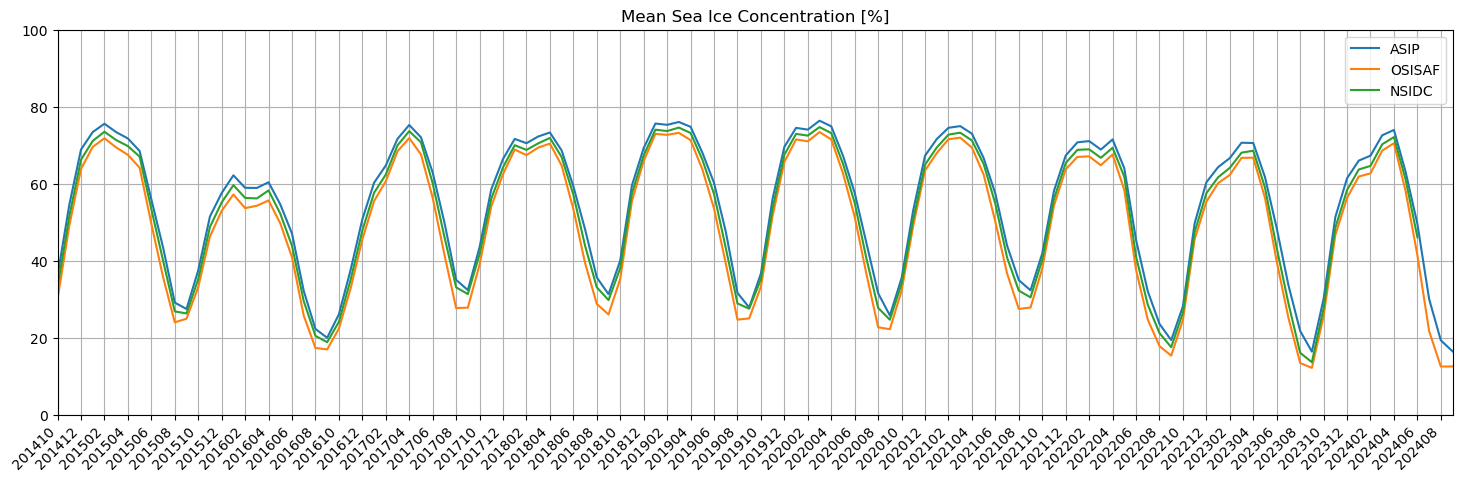

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))


# ASIP
color = 'tab:blue'
plt.plot(df.date, df.asip_osisaf_mean, label='ASIP', color=color)

# OSISAF
color = 'tab:orange'
plt.plot(df.date, df.osisaf_mean, label='OSISAF', color=color)

# NSIDC
color = 'tab:green'
plt.plot(df.date, df.nsidc_mean, label='NSIDC', color=color)


plt.grid(axis='y', which='both')
plt.grid(axis='x', which='both')

plt.title(f'Mean Sea Ice Concentration [%]')
plt.xticks(rotation=45, ha='right')
plt.xlim(0, len(df) - 1)
plt.ylim(0, 100)
plt.legend()

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=60))

#plt.savefig(f'plots/asip_v_osisaf_monthly_SIC_{scale}km.png', bbox_inches='tight', dpi=300)

### Geographical distribution of errors (OSI SAF)

In [ ]:
# Aggregate samples for all months

years = sorted(list(set([get_zarr_dt(zarr).year for zarr in zarrs])))
months = sorted(list(set([get_zarr_dt(zarr).month for zarr in zarrs])))

yearmonth_samples = {}
for year in tqdm(years):
    for month in months:
        zarr_subset = [zarr for zarr in zarrs if get_zarr_dt(zarr).year == year and get_zarr_dt(zarr).month == month]
        asip_tmp = []
        osisaf_tmp = []
        osisaf_raw_tmp = []
        nsidc_tmp = []
        nt2_tmp = []
        for zarr_path in zarr_subset:
            z = zarr.open(zarr_path, mode='r')
            asip = z.datasets.asip_sic[:]
            osisaf = z.datasets.osisaf[:]
            osisaf_raw = z.datasets.osisaf_raw[:]
            nsidc = z.datasets.nsidc[:]
            nt2 = z.datasets.nt2[:]
            asip_tmp.append(asip)
            osisaf_tmp.append(osisaf)
            osisaf_raw_tmp.append(osisaf_raw)
            nsidc_tmp.append(nsidc)
            nt2_tmp.append(nt2)

        
        if len(asip_tmp) > 0:
            yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {
                'asip': np.stack(asip_tmp), 
                'osisaf': np.stack(osisaf_tmp),
                'osisaf_raw': np.stack(osisaf_raw_tmp), 
                'nsidc': np.stack(nsidc_tmp),
                'nt2': np.stack(nt2_tmp)
                }

#del yearmonth_samples['202410'] # October 2024 only contains a couple of days

100%|██████████| 11/11 [02:54<00:00, 15.86s/it]


In [4]:
asip_months = {}
osisaf_months = {}
osisaf_raw_months = {}
nsidc_months = {}
nt2_months = {}

for month in months:
    asip_tmp = []
    osisaf_tmp = []
    osisaf_raw_tmp = []
    nsidc_tmp = []
    nt2_tmp = []
    for year in years:
        key = ''.join([str(year), str(month).zfill(2)])
        if key in yearmonth_samples.keys():
            asip_tmp.append(yearmonth_samples[key]['asip'])
            osisaf_tmp.append(yearmonth_samples[key]['osisaf'])
            osisaf_raw_tmp.append(yearmonth_samples[key]['osisaf_raw'])
            nsidc_tmp.append(yearmonth_samples[key]['nsidc'])
            nt2_tmp.append(yearmonth_samples[key]['nt2'])

    asip_tmp = np.vstack(asip_tmp)
    osisaf_tmp = np.vstack(osisaf_tmp)
    osisaf_raw_tmp = np.vstack(osisaf_raw_tmp)
    nsidc_tmp = np.vstack(nsidc_tmp)
    nt2_tmp = np.vstack(nt2_tmp)
    invalid = np.isnan(asip_tmp) + np.isnan(osisaf_tmp) + np.isnan(osisaf_raw_tmp) + np.isnan(nsidc_tmp) + np.isnan(nt2_tmp)
    asip_tmp[invalid] = np.nan
    osisaf_tmp[invalid] = np.nan
    osisaf_raw_tmp[invalid] = np.nan
    nsidc_tmp[invalid] = np.nan
    nt2_tmp[invalid] = np.nan


    asip_months[str(month).zfill(2)] = asip_tmp
    osisaf_months[str(month).zfill(2)] = osisaf_tmp
    osisaf_raw_months[str(month).zfill(2)] = osisaf_raw_tmp
    nsidc_months[str(month).zfill(2)] = nsidc_tmp
    nt2_months[str(month).zfill(2)] = nt2_tmp


In [ ]:
# for grid-cell-wise average across the 10 years
for month in [6, 7, 8]:
    diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
    print(np.nanquantile(diff, [0.10, 0.90]))

/tmp/ipykernel_2156033/3603973739.py:2: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)


[ 0.         17.38826527]
[ 0.         20.03059341]
[ 0.         18.97655636]


In [ ]:
# for all matched grid cells
for month in [6, 7, 8]:
    print(np.nanquantile(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], [0.10, 0.90]))

[ 0.         23.49999237]
[ 0.   25.84]
[ 0.         26.30998474]


In [81]:
# for all matched grid cells
for month in [6, 7, 8]:
    print(np.nanquantile(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], [0.10, 0.90]))

[-1.         16.62511826]
[-7.62939453e-06  1.80000076e+01]
[-1.         16.24984093]


In [60]:
asip_months[str(month).zfill(2)].shape

(309, 250, 240)

In [33]:
np.nanmax(diff)

np.float64(68.95000762939452)

In [37]:
np.nanmean(diff[100:150, 50:100])

np.float64(15.215072194521396)

In [38]:
diff

array([[ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

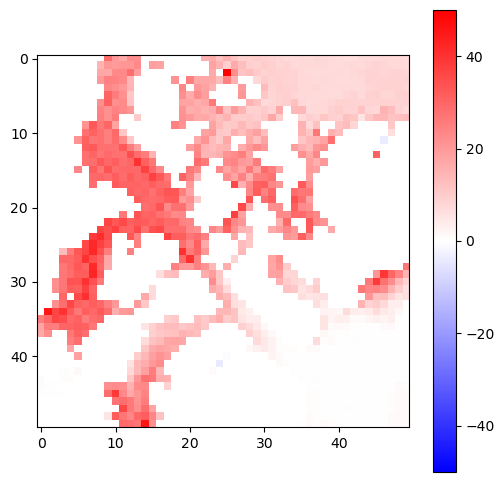

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(diff[100:150, 50:100], vmin=-50, vmax=50, cmap='bwr')
plt.colorbar()

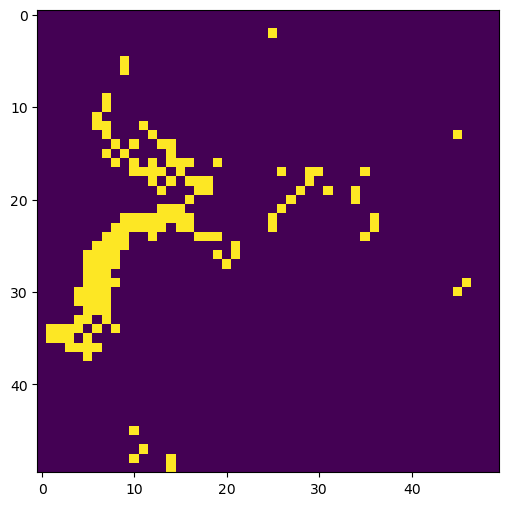

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(diff[100:150, 50:100] > 30)

/tmp/ipykernel_1952532/1097243945.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1097243945.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1097243945.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1097243945.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1097243945.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1097243945.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).

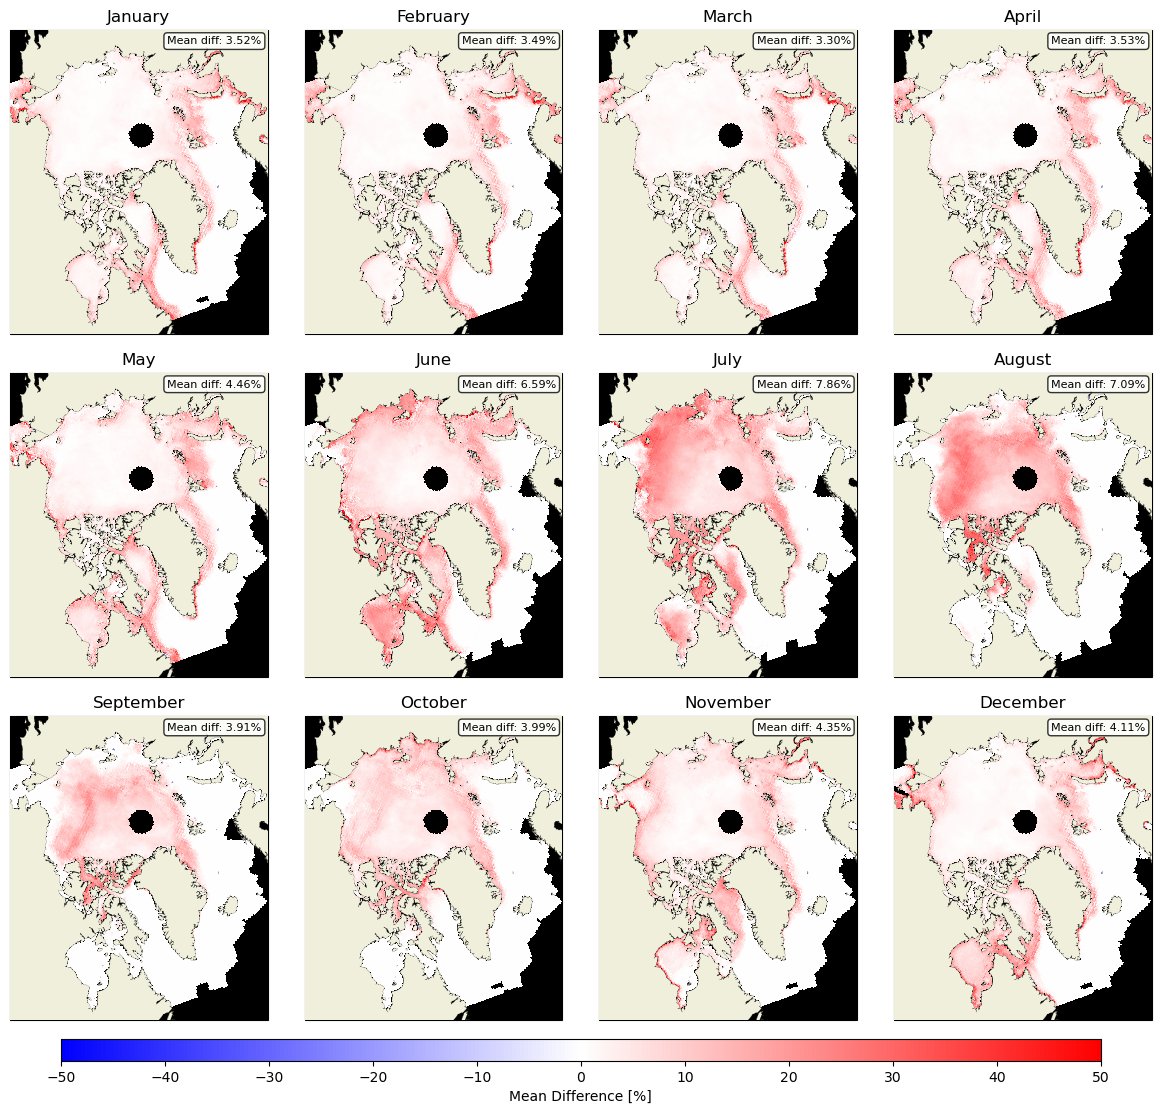

In [5]:
# Cartopy plot
import matplotlib
import numpy as np
import cartopy
import matplotlib.pyplot as plt
from datetime import datetime

cmap = plt.cm.bwr

lon = np.load(f'lon_{scale}km.npy')
lat = np.load(f'lat_{scale}km.npy')

fig, axes = plt.subplots(3, 4, figsize=(13, 11), subplot_kw={'projection': cartopy.crs.NorthPolarStereo(central_longitude=-65)})
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.03, hspace=0.13)
for i, ax in enumerate(axes.flat):
    if i < len(months):
        month = str(months[i]).zfill(2)
        diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)

        ax.set_extent([-4e6, 2e6, -2.3e6, 1.5e6], cartopy.crs.NorthPolarStereo())
        ax.add_feature(cartopy.feature.OCEAN, color='black', zorder=100)
        ax.add_feature(cartopy.feature.LAND, zorder=103)
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.1, zorder=104)
        
        im = ax.pcolormesh(lon, lat, diff, transform=cartopy.crs.PlateCarree(), zorder=102, cmap=cmap, vmin=-50, vmax=50)

        mean_diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)])
        ax.text(0.61, 0.98, f'Mean diff: {mean_diff:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=105)

        ax.set_title(f'{datetime.strptime(month, "%m").strftime("%B")}')
    else:
        ax.axis('off')

cbar_ax = fig.add_axes([0.1, 0.013, 0.8, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean Difference [%]')
cbar.set_ticks(np.arange(-50, 51, 10))

#plt.savefig(f'paper_plots/asip_v_osisaf_monthly_diff_{scale}km.png', bbox_inches='tight', dpi=300)
#plt.close()

/tmp/ipykernel_1952532/4263006384.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/4263006384.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/4263006384.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/4263006384.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/4263006384.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/4263006384.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill

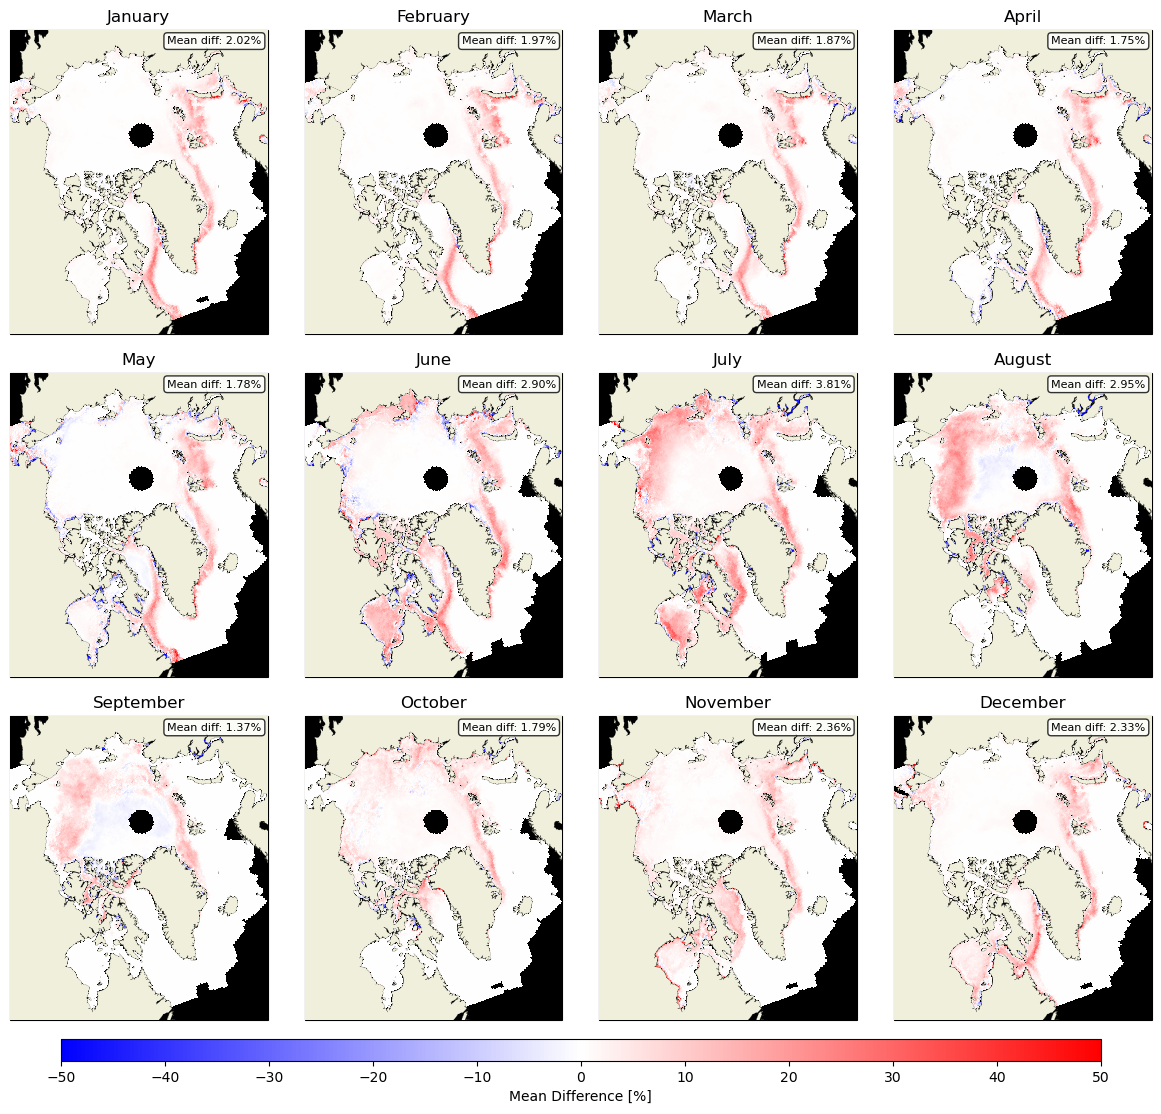

In [6]:
# Cartopy plot
import matplotlib
import numpy as np
import cartopy
import matplotlib.pyplot as plt
from datetime import datetime

cmap = plt.cm.bwr

lon = np.load(f'lon_{scale}km.npy')
lat = np.load(f'lat_{scale}km.npy')

fig, axes = plt.subplots(3, 4, figsize=(13, 11), subplot_kw={'projection': cartopy.crs.NorthPolarStereo(central_longitude=-65)})
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.03, hspace=0.13)
for i, ax in enumerate(axes.flat):
    if i < len(months):
        month = str(months[i]).zfill(2)
        diff = np.nanmean(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)

        ax.set_extent([-4e6, 2e6, -2.3e6, 1.5e6], cartopy.crs.NorthPolarStereo())
        ax.add_feature(cartopy.feature.OCEAN, color='black', zorder=100)
        ax.add_feature(cartopy.feature.LAND, zorder=103)
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.1, zorder=104)
        
        im = ax.pcolormesh(lon, lat, diff, transform=cartopy.crs.PlateCarree(), zorder=102, cmap=cmap, vmin=-50, vmax=50)

        mean_diff = np.nanmean(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)])
        ax.text(0.61, 0.98, f'Mean diff: {mean_diff:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=105)

        ax.set_title(f'{datetime.strptime(month, "%m").strftime("%B")}')
    else:
        ax.axis('off')

cbar_ax = fig.add_axes([0.1, 0.013, 0.8, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean Difference [%]')
cbar.set_ticks(np.arange(-50, 51, 10))

#plt.savefig(f'paper_plots/asip_v_nsidc_monthly_diff_{scale}km.png', bbox_inches='tight', dpi=300)
#plt.close()

/tmp/ipykernel_1952532/1631663055.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1631663055.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1631663055.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1631663055.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1631663055.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1631663055.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asi

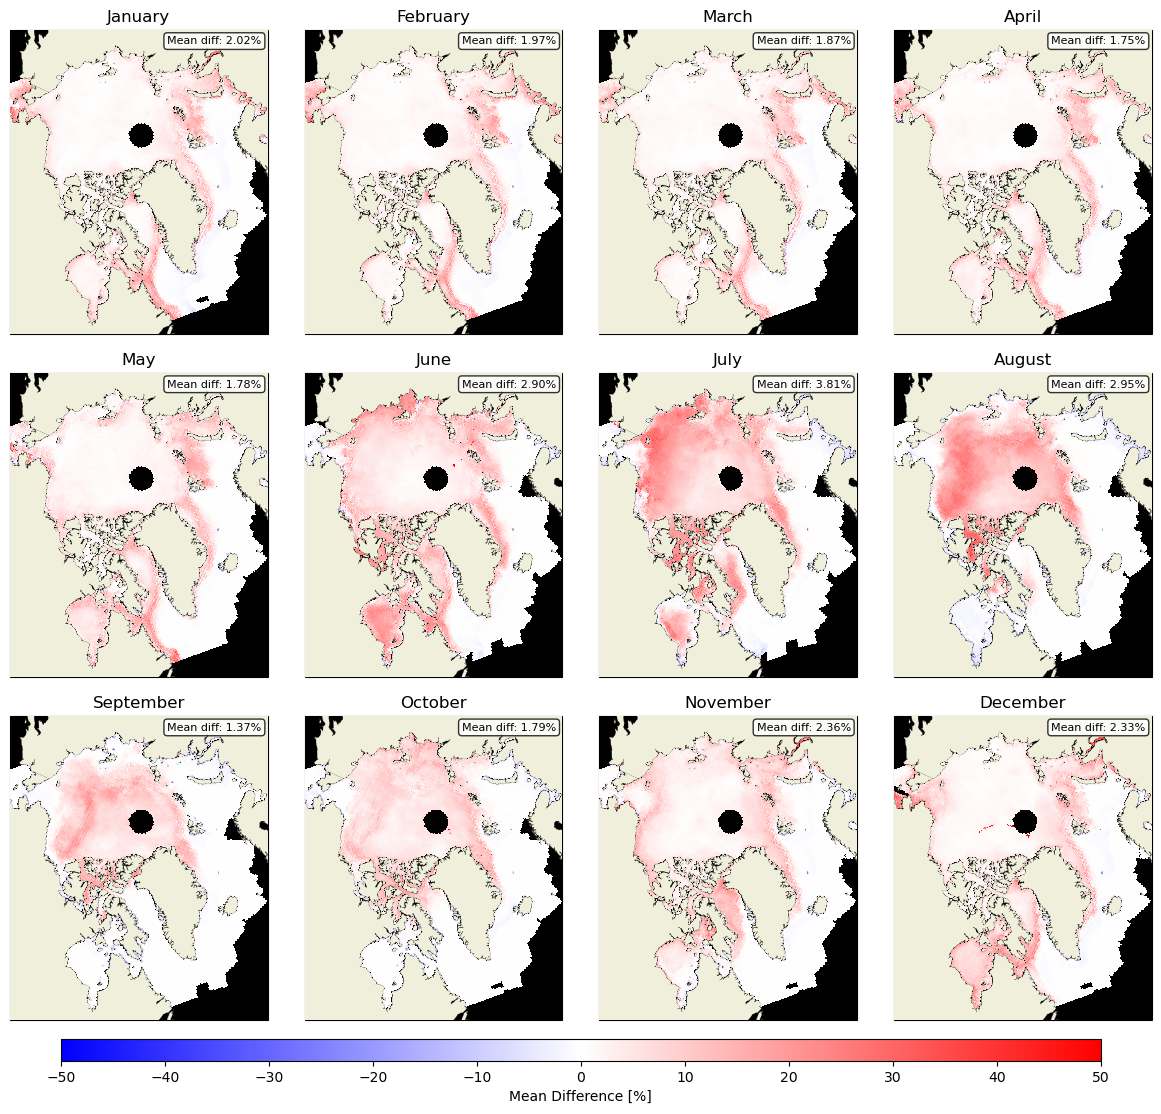

In [7]:
# Cartopy plot
import matplotlib
import numpy as np
import cartopy
import matplotlib.pyplot as plt
from datetime import datetime

cmap = plt.cm.bwr

lon = np.load(f'lon_{scale}km.npy')
lat = np.load(f'lat_{scale}km.npy')

fig, axes = plt.subplots(3, 4, figsize=(13, 11), subplot_kw={'projection': cartopy.crs.NorthPolarStereo(central_longitude=-65)})
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.03, hspace=0.13)
for i, ax in enumerate(axes.flat):
    if i < len(months):
        month = str(months[i]).zfill(2)
        diff = np.nanmean(asip_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)

        ax.set_extent([-4e6, 2e6, -2.3e6, 1.5e6], cartopy.crs.NorthPolarStereo())
        ax.add_feature(cartopy.feature.OCEAN, color='black', zorder=100)
        ax.add_feature(cartopy.feature.LAND, zorder=103)
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.1, zorder=104)
        
        im = ax.pcolormesh(lon, lat, diff, transform=cartopy.crs.PlateCarree(), zorder=102, cmap=cmap, vmin=-50, vmax=50)

        mean_diff = np.nanmean(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)])
        ax.text(0.61, 0.98, f'Mean diff: {mean_diff:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=105)

        ax.set_title(f'{datetime.strptime(month, "%m").strftime("%B")}')
    else:
        ax.axis('off')

cbar_ax = fig.add_axes([0.1, 0.013, 0.8, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean Difference [%]')
cbar.set_ticks(np.arange(-50, 51, 10))

plt.savefig(f'paper_plots/asip_v_osisaf_raw_monthly_diff_{scale}km.png', bbox_inches='tight', dpi=300)
#plt.close()

/tmp/ipykernel_1952532/1887444162.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1887444162.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1887444162.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1887444162.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1887444162.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_1952532/1887444162.py:18: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(asip_months[str(month).zfill(2)] - nt2

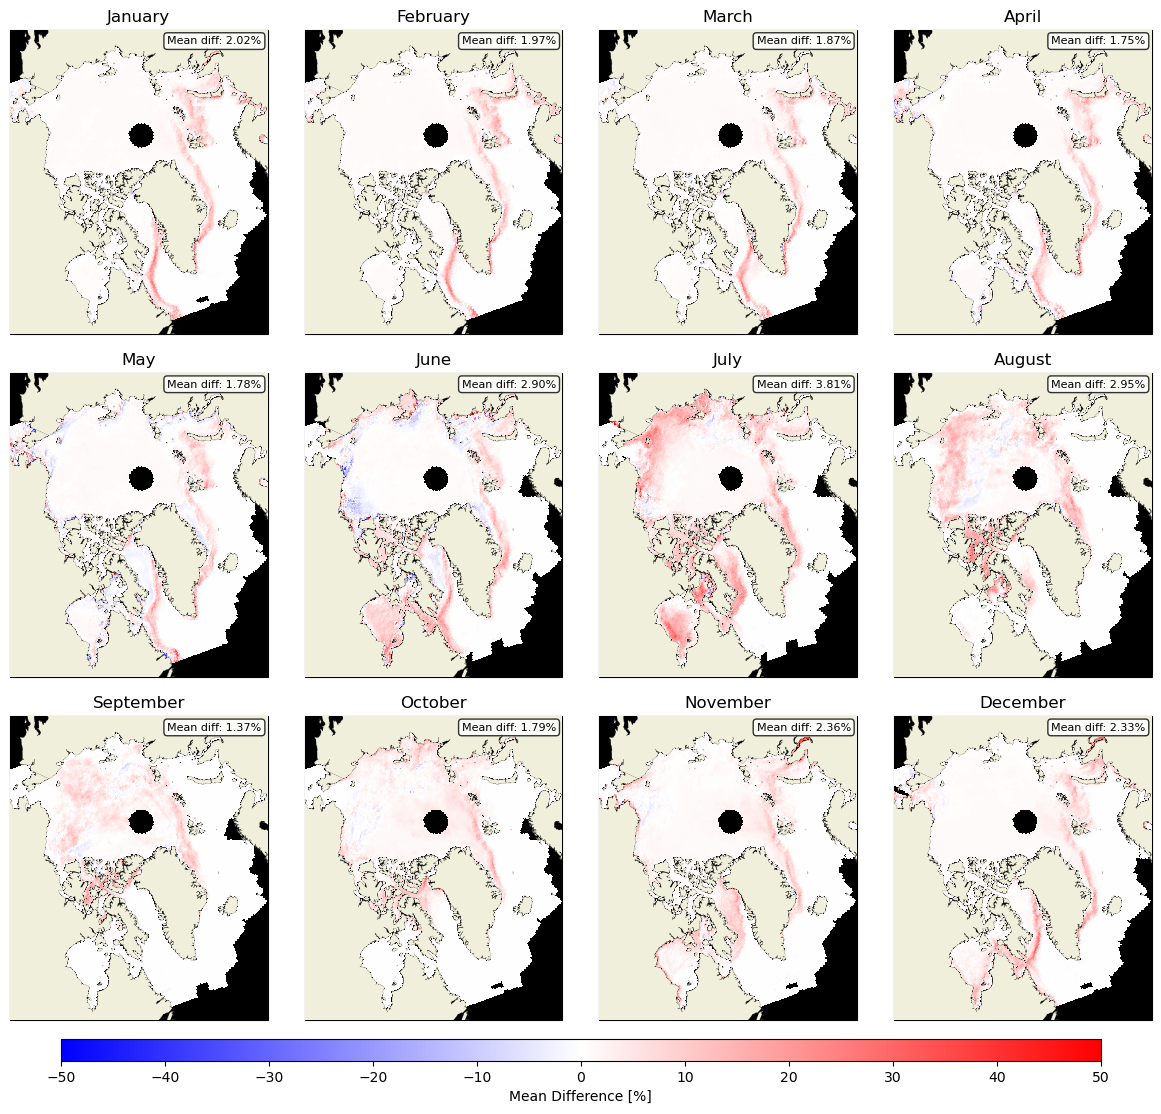

In [8]:
# Cartopy plot
import matplotlib
import numpy as np
import cartopy
import matplotlib.pyplot as plt
from datetime import datetime

cmap = plt.cm.bwr

lon = np.load(f'lon_{scale}km.npy')
lat = np.load(f'lat_{scale}km.npy')

fig, axes = plt.subplots(3, 4, figsize=(13, 11), subplot_kw={'projection': cartopy.crs.NorthPolarStereo(central_longitude=-65)})
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.03, hspace=0.13)
for i, ax in enumerate(axes.flat):
    if i < len(months):
        month = str(months[i]).zfill(2)
        diff = np.nanmean(asip_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)

        ax.set_extent([-4e6, 2e6, -2.3e6, 1.5e6], cartopy.crs.NorthPolarStereo())
        ax.add_feature(cartopy.feature.OCEAN, color='black', zorder=100)
        ax.add_feature(cartopy.feature.LAND, zorder=103)
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.1, zorder=104)
        
        im = ax.pcolormesh(lon, lat, diff, transform=cartopy.crs.PlateCarree(), zorder=102, cmap=cmap, vmin=-50, vmax=50)

        mean_diff = np.nanmean(asip_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)])
        ax.text(0.61, 0.98, f'Mean diff: {mean_diff:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=105)

        ax.set_title(f'{datetime.strptime(month, "%m").strftime("%B")}')
    else:
        ax.axis('off')

cbar_ax = fig.add_axes([0.1, 0.013, 0.8, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean Difference [%]')
cbar.set_ticks(np.arange(-50, 51, 10))

plt.savefig(f'paper_plots/asip_v_nt2_monthly_diff_{scale}km.png', bbox_inches='tight', dpi=300)
#plt.close()

# Comparison with Landsat

In [22]:
import os
import glob
import zarr
import numpy as np
from tqdm import tqdm
import dateutil

def get_zarr_dt(zarr_path):
    return dateutil.parser.parse(os.path.basename(zarr_path).split('.')[0])

scale = '25'
zarrs = sorted(glob.glob(f'cci_data/*.zarr'))


In [23]:
# Aggregate samples for all months and years

years = sorted(list(set([get_zarr_dt(zarr).year for zarr in zarrs])))
months = sorted(list(set([get_zarr_dt(zarr).month for zarr in zarrs])))

years = [2020, 2021, 2022]

yearmonth_samples = {}
for year in tqdm(years):
    for month in months:
        zarr_subset = [zarr for zarr in zarrs if get_zarr_dt(zarr).year == year and get_zarr_dt(zarr).month == month]
        asip_tmp = []
        osisaf_tmp = []
        osisaf_raw_tmp = []
        nsidc_tmp = []
        nt2_tmp = []
        landsat_tmp = []
        for zarr_path in zarr_subset:
            z = zarr.open(zarr_path, mode='r')
            asip = z.datasets.asip_sic[:]
            osisaf = z.datasets.osisaf[:]
            osisaf_raw = z.datasets.osisaf_raw[:]
            nsidc = z.datasets.nsidc[:]
            nt2 = z.datasets.nt2[:]
            landsat = z.datasets.landsat[:]
            valid_mask = ~(np.isnan(asip) + np.isnan(osisaf) + np.isnan(osisaf_raw) + np.isnan(nsidc) + np.isnan(nt2) + np.isnan(landsat))
            if valid_mask.any(): # Appending all pixels with valid data
                asip_tmp.append(asip[valid_mask])
                osisaf_tmp.append(osisaf[valid_mask])
                osisaf_raw_tmp.append(osisaf_raw[valid_mask])
                nsidc_tmp.append(nsidc[valid_mask])
                nt2_tmp.append(nt2[valid_mask])
                landsat_tmp.append(landsat[valid_mask])

        
        if len(asip_tmp) > 0:
            yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {
                'asip': np.hstack(asip_tmp), 
                'osisaf': np.hstack(osisaf_tmp), 
                'osisaf_raw': np.hstack(osisaf_raw_tmp),
                'nsidc': np.hstack(nsidc_tmp), 
                'nt2': np.hstack(nt2_tmp), 
                'landsat': np.hstack(landsat_tmp)}
        else:
            yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {
                'asip': np.array([]), 
                'osisaf': np.array([]),
                'osisaf_raw': np.array([]), 
                'nsidc': np.array([]), 
                'nt2': np.array([]),
                'landsat': np.array([])}

100%|██████████| 3/3 [00:59<00:00, 19.75s/it]


In [24]:
# get all samples

asip = np.hstack([yearmonth_samples[yearmonth]['asip'] for yearmonth in yearmonth_samples])
osisaf = np.hstack([yearmonth_samples[yearmonth]['osisaf'] for yearmonth in yearmonth_samples])
osisaf_raw = np.hstack([yearmonth_samples[yearmonth]['osisaf_raw'] for yearmonth in yearmonth_samples])
nsidc = np.hstack([yearmonth_samples[yearmonth]['nsidc'] for yearmonth in yearmonth_samples])
nt2 = np.hstack([yearmonth_samples[yearmonth]['nt2'] for yearmonth in yearmonth_samples])
landsat = np.hstack([yearmonth_samples[yearmonth]['landsat'] for yearmonth in yearmonth_samples])

In [25]:
from sklearn.metrics import root_mean_squared_error

# RMSE

print('RMSE')
print(f'ASIP: {root_mean_squared_error(landsat, asip)}')
print(f'OSISAF: {root_mean_squared_error(landsat, osisaf)}')
print(f'OSISAF RAW: {root_mean_squared_error(landsat, osisaf_raw)}')
print(f'NSIDC: {root_mean_squared_error(landsat, nsidc)}')
print(f'NT2: {root_mean_squared_error(landsat, nt2)}')

#ASIP: 8.691811123880315
#OSISAF: 12.146302296640506
#NSIDC: 13.567394893284467

RMSE
ASIP: 8.714223430490735
OSISAF: 12.164667555575091
OSISAF RAW: 9.878417534191176
NSIDC: 13.585956373802441
NT2: 11.195612921635245


In [26]:
# Mean bias

print(f'ASIP: {np.mean(asip - landsat)}')
print(f'OSISAF: {np.mean(osisaf - landsat)}')
print(f'OSISAF RAW: {np.mean(osisaf_raw - landsat)}')
print(f'NSIDC: {np.mean(nsidc - landsat)}')
print(f'NT2: {np.mean(asip - nt2)}')

#ASIP: 2.4800526871937247
#OSISAF: -4.054673198041042
#NSIDC: 0.8327197390392856

ASIP: 2.4884826577506796
OSISAF: -4.057633629538794
OSISAF RAW: -2.615917610182176
NSIDC: 0.8285020673746766
NT2: 1.730185941026656


### Performance across SIC bins

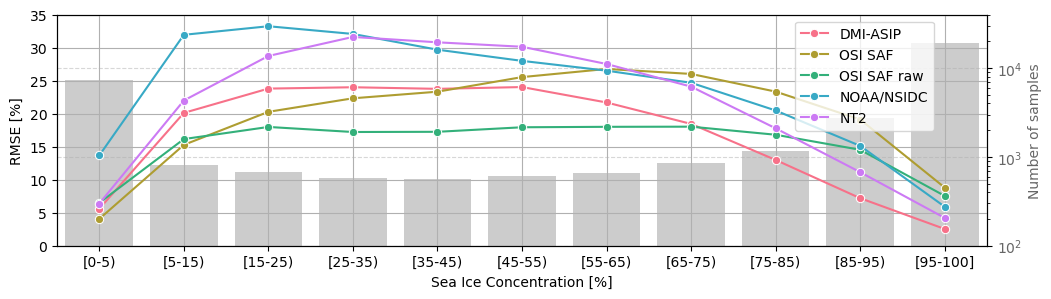

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import root_mean_squared_error


# Define the bins
bins = [0, 5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 100]

# Initialize lists to store RMSE and bias values for each bin
rmse_asip_bins = []
rmse_osisaf_bins = []
rmse_osisaf_raw_bins = []
rmse_nsidc_bins = []
rmse_nt2_bins = []
bin_support = []

# Calculate RMSE for each bin
for i in range(len(bins) - 1):
    if bins[i] == 95:
        mask = (landsat >= bins[i]) & (landsat <= bins[i+1])
    else:
        mask = (landsat >= bins[i]) & (landsat < bins[i+1])

    if np.any(mask):
        rmse_asip_bins.append(root_mean_squared_error(landsat[mask], asip[mask]))
        rmse_osisaf_bins.append(root_mean_squared_error(landsat[mask], osisaf[mask]))
        rmse_osisaf_raw_bins.append(root_mean_squared_error(landsat[mask], osisaf_raw[mask]))
        rmse_nsidc_bins.append(root_mean_squared_error(landsat[mask], nsidc[mask]))
        rmse_nt2_bins.append(root_mean_squared_error(landsat[mask], nt2[mask]))
        bin_support.append(np.sum(mask))

# Create a DataFrame for bin support
data_support = {
    'Support': bin_support,
    'Bin': [f'[{bins[i]}-{bins[i+1]})' if bins[i] != 95 else f'[{bins[i]}-{bins[i+1]}]' for i in range(len(bins) - 1)]
}

df_support_bins = pd.DataFrame(data_support, columns=['Support', 'Bin'])

# Set color palette
sns.set_palette(['tab:green', 'tab:blue', 'tab:orange'])

# Create a DataFrame for plotting
data_rmse = {
    'RMSE': rmse_asip_bins + rmse_osisaf_bins + rmse_osisaf_raw_bins + rmse_nsidc_bins + rmse_nt2_bins,
    'Dataset': ['DMI-ASIP'] * len(rmse_asip_bins) + ['OSI SAF'] * len(rmse_osisaf_bins) + ['OSI SAF raw'] * len(rmse_osisaf_raw_bins) + ['NOAA/NSIDC'] * len(rmse_nsidc_bins) + ['NT2'] * len(rmse_nt2_bins),
    'Bin': [f'[{bins[i]}-{bins[i+1]})' if bins[i] != 95 else f'[{bins[i]}-{bins[i+1]}]' for i in range(len(bins) - 1)] * 5
}

df_rmse_bins = pd.DataFrame(data_rmse, columns=['RMSE', 'Dataset', 'Bin'])

fig, ax1 = plt.subplots(figsize=(12, 3))
sns.lineplot(x='Bin', y='RMSE', hue='Dataset', data=df_rmse_bins, marker='o', zorder=2)
ax1.set_ylabel(r'RMSE [%]')
ax1.set_xlabel('Sea Ice Concentration [%]')
ax1.set_ylim(0, 35)
ax1.grid(True, zorder=0)
ax1.legend(loc='upper right', bbox_to_anchor=(0.95, 1))

ax2 = ax1.twinx()
ax2.set_zorder(0) # Send ax2 to the background
ax1.set_zorder(1) # Bring ax1 to the foreground
ax1.patch.set_visible(False) # Make ax1's background transparent to see ax2

sns.barplot(x='Bin', y='Support', data=df_support_bins, alpha=0.4, ax=ax2, color='gray')
ax2.set_yscale('log', base=10)
ax2.set_ylim(100, 40000)
ax2.set_ylabel('Number of samples', alpha=0.6)
#ax2.legend(['Support'], loc='upper right')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

for tl in ax2.get_yticklabels():
    tl.set_alpha(0.6)

plt.savefig(f'paper_plots/rmse_plot_updated.png', bbox_inches='tight', dpi=300)

plt.show()

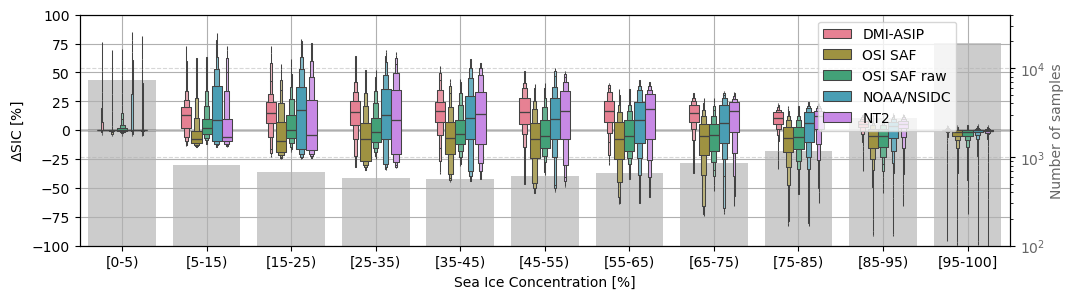

In [28]:
bias_asip_bins = []
bias_osisaf_bins = []
bias_osisaf_raw_bins = []
bias_nsidc_bins = []
bias_nt2_bins = []
bin = []

# Calculate bias for each bin
for i in range(len(bins) - 1):
    if bins[i] == 95:
        mask = (landsat >= bins[i]) & (landsat <= bins[i+1])
    else:
        mask = (landsat >= bins[i]) & (landsat < bins[i+1])

    if np.any(mask):
        bias_asip_bins.append(asip[mask] - landsat[mask])
        bias_osisaf_bins.append(osisaf[mask] - landsat[mask])
        bias_osisaf_raw_bins.append(osisaf_raw[mask] - landsat[mask])
        bias_nsidc_bins.append(nsidc[mask] - landsat[mask])
        bias_nt2_bins.append(nt2[mask] - landsat[mask])
        bin.append([f'[{bins[i]}-{bins[i+1]})'] * np.sum(mask) if bins[i] != 95 else [f'[{bins[i]}-{bins[i+1]}]'] * np.sum(mask))

bin = [item for sublist in bin for item in sublist]

# Create a DataFrame for plotting
data_bias = {
    'Bias': np.hstack(bias_asip_bins).tolist() + np.hstack(bias_osisaf_bins).tolist() + np.hstack(bias_osisaf_raw_bins).tolist() + np.hstack(bias_nsidc_bins).tolist() + np.hstack(bias_nt2_bins).tolist(),
    'Bin': bin * 5,
    'Dataset': ['DMI-ASIP'] * len(np.hstack(bias_asip_bins)) + ['OSI SAF'] * len(np.hstack(bias_osisaf_bins)) + ['OSI SAF raw'] * len(np.hstack(bias_osisaf_raw_bins)) + ['NOAA/NSIDC'] * len(np.hstack(bias_nsidc_bins)) + ['NT2'] * len(np.hstack(bias_nt2_bins))
}

df_bias_bins = pd.DataFrame(data_bias, columns=['Bias', 'Bin', 'Dataset'])


fig, ax1 = plt.subplots(figsize=(12, 3))
ax1.axhline(0, color='black', lw=1, zorder=1)
sns.boxenplot(x='Bin', y='Bias', hue='Dataset', data=df_bias_bins, showfliers=False, width=0.6, ax=ax1, zorder=2) 
ax1.set_ylabel(r'$\Delta$SIC [%]')
ax1.set_xlabel('Sea Ice Concentration [%]')
ax1.set_ylim(-100, 100)
ax1.grid(True, zorder=0)
ax1.legend(loc='upper right', bbox_to_anchor=(0.95, 1))

ax2 = ax1.twinx()
ax2.set_zorder(0) # Send ax2 to the background
ax1.set_zorder(1) # Bring ax1 to the foreground
ax1.patch.set_visible(False) # Make ax1's background transparent to see ax2

# Plot on the secondary axis (ax2)
sns.barplot(x='Bin', y='Support', data=df_support_bins, alpha=0.4, ax=ax2, color='gray')
ax2.set_yscale('log', base=10)
ax2.set_ylim(100, 40000)
ax2.set_ylabel('Number of samples', alpha=0.6)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

for tl in ax2.get_yticklabels():
    tl.set_alpha(0.6)

plt.savefig(f'paper_plots/bias_plot_updated.png', bbox_inches='tight', dpi=300)

plt.show()

### Performance across months

In [18]:
# Get monthly data

asip_months, osisaf_months, osisaf_raw_months, nsidc_months, nt2_months, landsat_months = {}, {}, {}, {}, {}, {}
for month in months:
    asip_months[month] = np.hstack([yearmonth_samples[yearmonth]['asip'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    osisaf_months[month] = np.hstack([yearmonth_samples[yearmonth]['osisaf'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    osisaf_raw_months[month] = np.hstack([yearmonth_samples[yearmonth]['osisaf_raw'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    nsidc_months[month] = np.hstack([yearmonth_samples[yearmonth]['nsidc'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    nt2_months[month] = np.hstack([yearmonth_samples[yearmonth]['nt2'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    landsat_months[month] = np.hstack([yearmonth_samples[yearmonth]['landsat'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])


In [19]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

min_support = 500

month_plot = []
monthly_rmse_asip, monthly_rmse_osisaf, monthly_rmse_osisaf_raw, monthly_rmse_nsidc, monthly_rmse_nt2, support = [], [], [], [], [], []
for month in months:
    if asip_months[month].size >= min_support:
        monthly_rmse_asip.append(root_mean_squared_error(landsat_months[month], asip_months[month]))
        monthly_rmse_osisaf.append(root_mean_squared_error(landsat_months[month], osisaf_months[month]))
        monthly_rmse_osisaf_raw.append(root_mean_squared_error(landsat_months[month], osisaf_raw_months[month]))
        monthly_rmse_nsidc.append(root_mean_squared_error(landsat_months[month], nsidc_months[month]))
        monthly_rmse_nt2.append(root_mean_squared_error(landsat_months[month], nt2_months[month]))
        support.append(asip_months[month].size)
        month_plot.append(month - 3)

/tmp/ipykernel_1952532/4042350529.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])


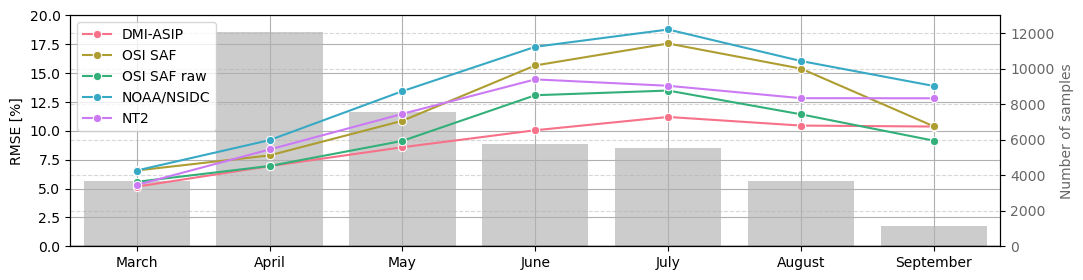

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# Set color palette
sns.set_palette(['tab:green', 'tab:blue', 'tab:orange'])

# Create a DataFrame for bin support
data_support = {
    'Support': support,
    'Yearmonth': month_plot
}

df_support_bins = pd.DataFrame(data_support, columns=['Support', 'Yearmonth'])

# Create a DataFrame for plotting
data_rmse = {
    'RMSE': monthly_rmse_asip + monthly_rmse_osisaf + monthly_rmse_osisaf_raw + monthly_rmse_nsidc + monthly_rmse_nt2,
    'Dataset': ['DMI-ASIP'] * len(month_plot) + ['OSI SAF'] * len(month_plot) + ['OSI SAF raw'] * len(month_plot) + ['NOAA/NSIDC'] * len(month_plot) + ['NT2'] * len(month_plot),
    'Yearmonth': month_plot * 5
}

df_rmse_bins = pd.DataFrame(data_rmse, columns=['RMSE', 'Dataset', 'Yearmonth'])

# plt.figure(figsize=(12, 3))
# sns.lineplot(x='Yearmonth', y='RMSE', hue='Dataset', data=df_rmse_bins, marker='o')
# plt.legend(loc='upper left')
# plt.ylabel('RMSE [%]')
# plt.xlabel('')
# plt.xticks(rotation=0)
# plt.grid(True)

# # change x-axis ticks to January, February, etc.
# plt.gca().set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])
# plt.ylim(0, 20)


fig, ax1 = plt.subplots(figsize=(12, 3))
ax1.axhline(0, color='black', lw=1, zorder=1)
sns.lineplot(x='Yearmonth', y='RMSE', hue='Dataset', data=df_rmse_bins, marker='o', ax=ax1, zorder=2)
ax1.set_ylabel(r'RMSE [%]')
ax1.set_xlabel('')
ax1.set_ylim(0, 20)
ax1.grid(True, zorder=0)
ax1.legend(loc='upper left') #bbox_to_anchor=(0.91, 1))
ax1.set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])

ax2 = ax1.twinx()
ax2.set_zorder(0) # Send ax2 to the background
ax1.set_zorder(1) # Bring ax1 to the foreground
ax1.patch.set_visible(False) # Make ax1's background transparent to see ax2


sns.barplot(x='Yearmonth', y='Support', data=df_support_bins, alpha=0.4, ax=ax2, color='gray', order=month_plot)
ax2.set_ylim(0, 13000)
ax2.set_ylabel('Number of samples', alpha=0.6)
#ax2.legend(['Support'], loc='upper right')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

for tl in ax2.get_yticklabels():
    tl.set_alpha(0.6)

plt.savefig(f'paper_plots/rmse_season_plot_updated.png', bbox_inches='tight', dpi=300)

plt.show()

In [73]:
min_support = 500

month_plot = []
sample_months = []
monthly_bias_asip, monthly_bias_osisaf, monthly_bias_nsidc, support = [], [], [], []
for month in months:
    if asip_months[month].size >= min_support:
        monthly_bias_asip.append(asip_months[month] - landsat_months[month])
        monthly_bias_osisaf.append(osisaf_months[month] - landsat_months[month])
        monthly_bias_nsidc.append(nsidc_months[month] - landsat_months[month])
        sample_months.append([month - 1]*asip_months[month].size)
    support.append(asip_months[month].size)
    month_plot.append(month - 1)

monthly_bias_asip = np.hstack(monthly_bias_asip).tolist()
monthly_bias_osisaf = np.hstack(monthly_bias_osisaf).tolist()
monthly_bias_nsidc = np.hstack(monthly_bias_nsidc).tolist()
sample_months = [item for sublist in sample_months for item in sublist]


/tmp/ipykernel_3805290/42469110.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])


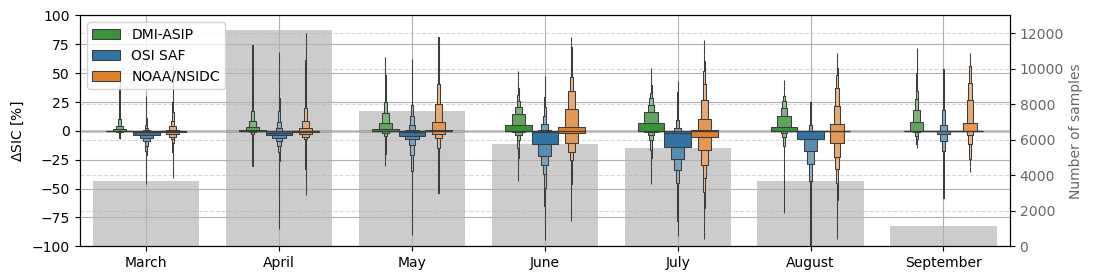

In [77]:
fig, ax1 = plt.subplots(figsize=(12, 3))

# Create a DataFrame for bin support
data_support = {
    'Support': support,
    'Yearmonth': month_plot
}

df_support_bins = pd.DataFrame(data_support, columns=['Support', 'Yearmonth'])

data_bias = {
    'Bias': monthly_bias_asip + monthly_bias_osisaf + monthly_bias_nsidc,
    'Yearmonth': sample_months * 3,
    'Dataset': ['DMI-ASIP'] * len(monthly_bias_asip) + ['OSI SAF'] * len(monthly_bias_osisaf) + ['NOAA/NSIDC'] * len(monthly_bias_nsidc)
}

df_bias_bins = pd.DataFrame(data_bias, columns=['Bias', 'Yearmonth', 'Dataset'])

plt.axhline(0, color='black', lw=1, zorder=1)
sns.boxenplot(x='Yearmonth', y='Bias', hue='Dataset', data=df_bias_bins, ax=ax1, order=month_plot[2:-3], width=0.6, showfliers=False, zorder=2)
ax1.set_ylabel(r'$\Delta$SIC [%]')
ax1.set_xlabel('')
ax1.set_xlim(0, 11)
ax1.set_ylim(-100, 100)
ax1.grid(True, zorder=0)
ax1.legend(loc='upper left')

# change x-axis ticks to January, February, etc.
ax1.set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])

ax2 = ax1.twinx()
ax2.set_zorder(0) # Send ax2 to the background
ax1.set_zorder(1) # Bring ax1 to the foreground
ax1.patch.set_visible(False) # Make ax1's background transparent to see ax2

sns.barplot(x='Yearmonth', y='Support', data=df_support_bins[2:-3], alpha=0.4, ax=ax2, color='gray', order=month_plot[2:-3])
ax2.set_ylim(0, 13000)
ax2.set_ylabel('Number of samples', alpha=0.6)
#ax2.legend(['Support'], loc='upper right')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

for tl in ax2.get_yticklabels():
    tl.set_alpha(0.6)

plt.savefig(f'paper_plots/bias_season_plot_revised1.png', bbox_inches='tight', dpi=300)

plt.show()